In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\abhin\Dropbox\PC\Downloads\projects\Customer Churn Prediction Platform\data\Telco-Customer-Churn.csv')

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [28]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df = df.drop("customerID", axis=1)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
df_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


## Train - Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

## Train - Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model = LogisticRegression(max_iter=1000, penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42, C=1.0)

pipeline = make_pipeline(StandardScaler(), model)
pipeline.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': pipeline.named_steps['logisticregression'].coef_[0]
})

feature_importance['Abd_Coefficient'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abd_Coefficient', ascending=False).drop(columns='Abd_Coefficient')

print(feature_importance)

scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print('Accuracy scores:', scores)
print('Mean accuracy:', scores.mean())

c:\Users\abhin\Dropbox\PC\Downloads\projects\Customer Churn Prediction Platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


                                  Feature  Importance
1                                  tenure   -1.427864
3                            TotalCharges    0.686923
25                      Contract_Two year   -0.585914
10            InternetService_Fiber optic    0.469129
24                      Contract_One year   -0.270584
2                          MonthlyCharges   -0.235330
26                   PaperlessBilling_Yes    0.168371
13                     OnlineSecurity_Yes   -0.164808
19                        TechSupport_Yes   -0.154196
28         PaymentMethod_Electronic check    0.145468
9                       MultipleLines_Yes    0.140725
23                    StreamingMovies_Yes    0.136534
21                        StreamingTV_Yes    0.130825
0                           SeniorCitizen    0.078871
6                          Dependents_Yes   -0.069936
7                        PhoneService_Yes   -0.068477
8          MultipleLines_No phone service    0.068477
15                       Onl

InvalidParameterError: The 'scoring' parameter of cross_val_score must be a str among {'completeness_score', 'neg_brier_score', 'recall', 'average_precision', 'matthews_corrcoef', 'r2', 'fowlkes_mallows_score', 'recall_weighted', 'positive_likelihood_ratio', 'top_k_accuracy', 'jaccard_samples', 'adjusted_rand_score', 'jaccard_weighted', 'neg_median_absolute_error', 'roc_auc', 'f1_samples', 'roc_auc_ovo_weighted', 'mutual_info_score', 'neg_mean_squared_log_error', 'f1', 'f1_weighted', 'jaccard_micro', 'homogeneity_score', 'neg_root_mean_squared_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_log_error', 'd2_absolute_error_score', 'neg_log_loss', 'precision', 'precision_micro', 'precision_samples', 'neg_mean_squared_error', 'rand_score', 'neg_mean_poisson_deviance', 'explained_variance', 'd2_log_loss_score', 'neg_mean_absolute_percentage_error', 'precision_macro', 'roc_auc_ovr_weighted', 'adjusted_mutual_info_score', 'neg_mean_gamma_deviance', 'roc_auc_ovr', 'neg_mean_abs

In [46]:
print("Accuracy :", scores["test_accuracy"].mean())

print("Precision:", scores["test_precision"].mean())

print("Recall :", scores["test_recall"].mean())

print("F1 :", scores["test_f1"].mean())

NameError: name 'scores' is not defined

## Evaluation

In [25]:
y_pred = model.predict(X_test_scaled)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8055358410220014
Precision: 0.65527950310559
Recall: 0.5641711229946524
F1: 0.6063218390804598
[[924 111]
 [163 211]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [11]:
coef = pd.DataFrame({'coefficient': model.coef_[0], 'feature': X_train.columns})

coef.sort_values(by='coefficient', ascending=False, inplace=True)

In [12]:
coef

,coefficient,feature
10,0.776154,InternetService_Fiber optic
3,0.514285,TotalCharges
23,0.257227,StreamingMovies_Yes
21,0.257144,StreamingTV_Yes
9,0.216167,MultipleLines_Yes
26,0.182034,PaperlessBilling_Yes
28,0.181103,PaymentMethod_Electronic check
0,0.053073,SeniorCitizen
17,0.053048,DeviceProtection_Yes
29,0.032262,PaymentMethod_Mailed check


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.7920511000709723
Precision: 0.6431095406360424
Recall: 0.48663101604278075
F1: 0.5540334855403348
[[934 101]
 [192 182]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



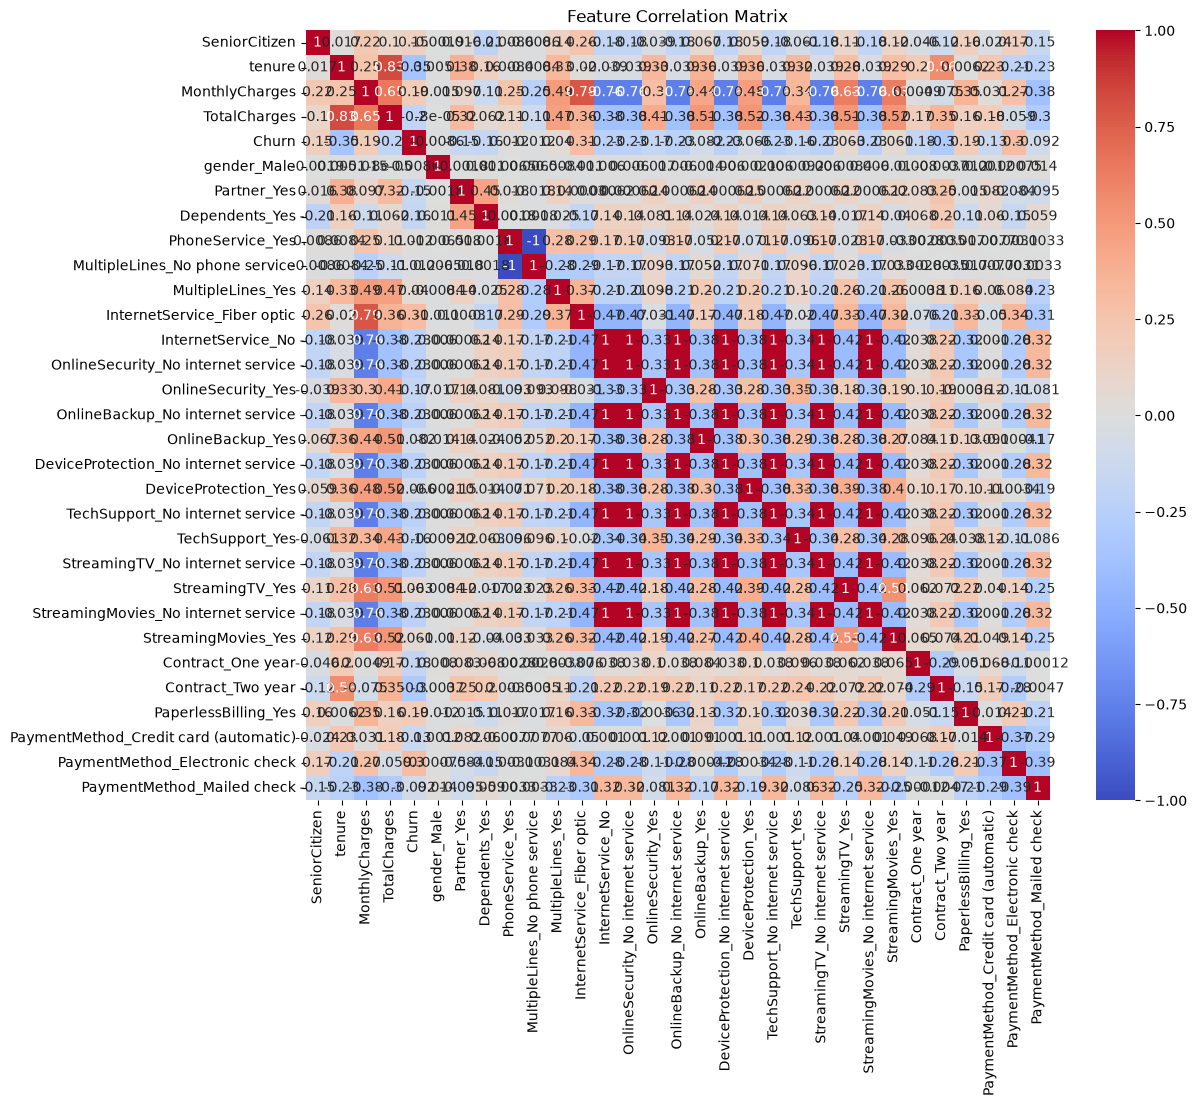

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

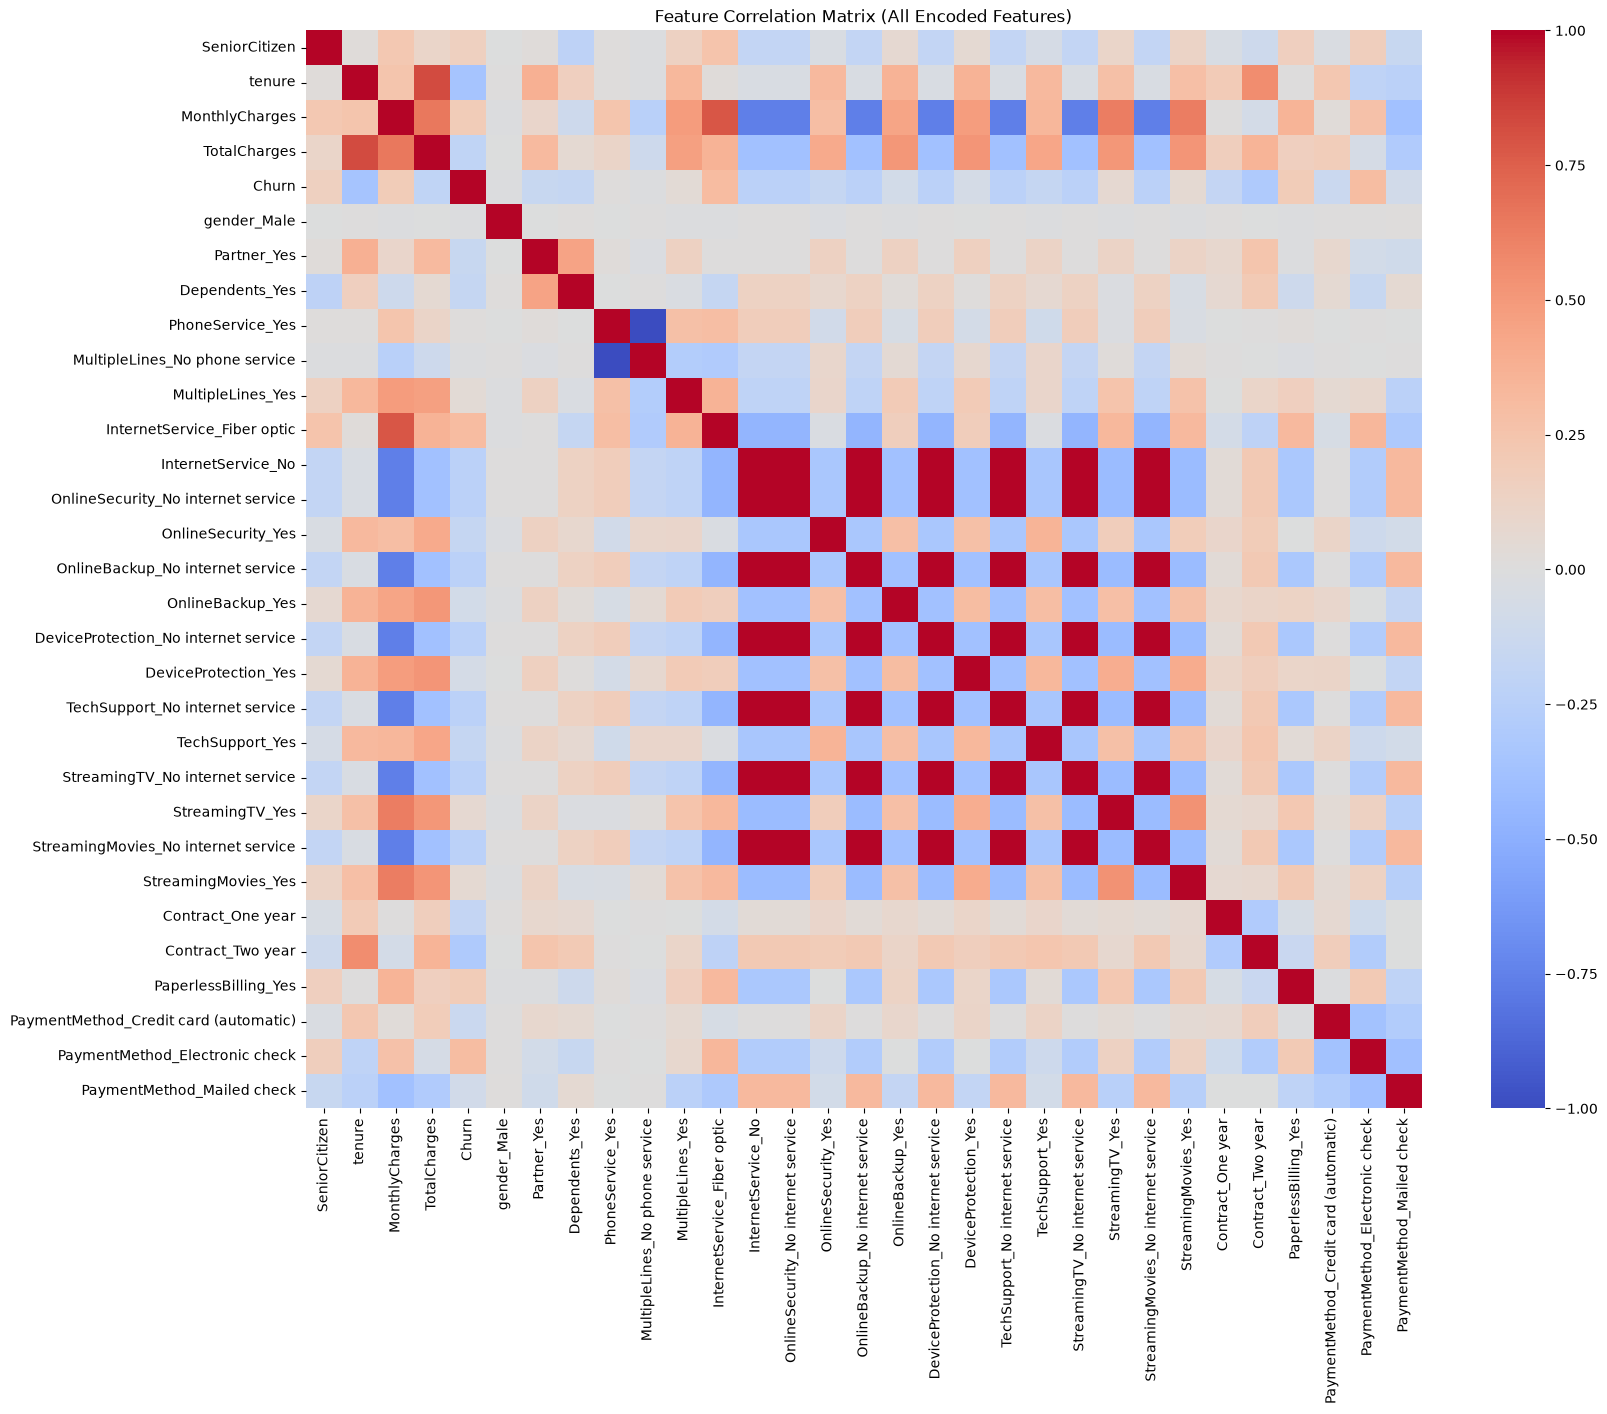

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (All Encoded Features)')
plt.show()